In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection, LineCollection
import numpy as np
import math

# --- Hex constants (flat-top, matches map3d.html) ---
HEX_SIZE = 1.0
SQRT3 = math.sqrt(3)
HEX_DIRS = [(1,0),(1,-1),(0,-1),(-1,0),(-1,1),(0,1)]
DIR_TO_GEO_EDGE = [0, 5, 4, 3, 2, 1]

def hex_to_world(q, r):
    x = HEX_SIZE * 1.5 * q
    y = HEX_SIZE * (SQRT3/2 * q + SQRT3 * r)
    return (x, y)

def hex_corner(wx, wy, i):
    a = math.pi / 3 * i
    return (wx + HEX_SIZE * math.cos(a), wy + HEX_SIZE * math.sin(a))

def hex_corners(q, r):
    wx, wy = hex_to_world(q, r)
    return [hex_corner(wx, wy, i) for i in range(6)]

def hex_center(q, r):
    return hex_to_world(q, r)

def edge_midpoint(q, r, geo_edge):
    c = hex_corners(q, r)
    a, b = c[geo_edge], c[(geo_edge+1) % 6]
    return ((a[0]+b[0])/2, (a[1]+b[1])/2)

print('Hex tools loaded.')

Hex tools loaded.


In [2]:
# --- Map data ---
BUILDING_HEXES = [
    (33,7),(32,8),(32,7),(31,7),(31,8),
    (37,3),(37,4),(37,5),(36,4),
    (38,6),(38,7),(39,6),
    (34,3),(33,3),(33,2),(34,2),
]
BUILDING_SET = set(BUILDING_HEXES)

MUR_SEGMENTS = [
    ((30,8),(31,8)),((30,9),(31,8)),((31,8),(31,9)),((31,8),(32,8)),((31,9),(32,8)),
    ((32,8),(32,9)),((32,8),(33,8)),((33,7),(33,8)),((33,7),(34,7)),((32,7),(33,6)),
    ((32,6),(32,7)),((30,7),(31,7)),((30,8),(31,7)),
    ((36,5),(37,5)),((36,6),(37,5)),((37,5),(37,6)),((37,5),(38,5)),((37,5),(38,4)),
    ((37,3),(38,3)),((37,3),(38,2)),((36,3),(37,3)),((37,2),(37,3)),
    ((36,3),(36,4)),((35,4),(36,4)),((35,5),(36,4)),((36,4),(36,5)),((36,5),(37,4)),
    ((37,6),(38,6)),((38,5),(38,6)),((38,6),(39,5)),((39,5),(39,6)),((39,6),(39,7)),
    ((38,7),(39,7)),((37,8),(38,7)),((37,7),(38,7)),((37,7),(38,6)),
    ((33,4),(34,3)),((34,3),(35,2)),((34,2),(35,2)),((34,2),(35,1)),
    ((34,1),(34,2)),((33,2),(34,1)),((33,1),(33,2)),((32,2),(33,2)),
    ((32,3),(33,2)),((32,3),(33,3)),((32,4),(33,3)),((33,3),(33,4)),
]

# Build lookup: (q1,r1,q2,r2) -> 'mur'  (both directions)
MUR_SET = set()
for (q1,r1),(q2,r2) in MUR_SEGMENTS:
    MUR_SET.add((q1,r1,q2,r2))
    MUR_SET.add((q2,r2,q1,r1))

def is_mur(q1, r1, q2, r2):
    return (q1,r1,q2,r2) in MUR_SET

# Cluster detection
def find_clusters(hexes):
    hset = set(hexes)
    visited = set()
    clusters = []
    for h in hexes:
        if h in visited: continue
        cluster = []
        queue = [h]
        visited.add(h)
        while queue:
            q, r = queue.pop(0)
            cluster.append((q, r))
            for dq, dr in HEX_DIRS:
                n = (q+dq, r+dr)
                if n in hset and n not in visited:
                    visited.add(n)
                    queue.append(n)
        clusters.append(cluster)
    return clusters

CLUSTERS = find_clusters(BUILDING_HEXES)
for i, c in enumerate(CLUSTERS):
    print(f'Cluster {i}: {len(c)} hexes — {c}')

Cluster 0: 5 hexes — [(33, 7), (32, 7), (32, 8), (31, 7), (31, 8)]
Cluster 1: 4 hexes — [(37, 3), (36, 4), (37, 4), (37, 5)]
Cluster 2: 3 hexes — [(38, 6), (39, 6), (38, 7)]
Cluster 3: 4 hexes — [(34, 3), (34, 2), (33, 3), (33, 2)]


In [3]:
# --- Drawing helpers ---

def draw_hex(ax, q, r, facecolor='#d4c8a8', edgecolor='#666', lw=0.8, alpha=0.5):
    """Draw a single hex."""
    corners = hex_corners(q, r)
    poly = MplPolygon(corners, closed=True, facecolor=facecolor, edgecolor=edgecolor, lw=lw, alpha=alpha)
    ax.add_patch(poly)

def draw_cluster(ax, cluster, facecolor='#d4c8a8', edgecolor='#666'):
    """Draw all hexes in a cluster."""
    for q, r in cluster:
        draw_hex(ax, q, r, facecolor=facecolor, edgecolor=edgecolor)

def draw_mur(ax, cluster, color='#555', lw=2.5):
    """Draw mur walls around a cluster."""
    cset = set(cluster)
    for q, r in cluster:
        for d, (dq, dr) in enumerate(HEX_DIRS):
            nq, nr = q+dq, r+dr
            if is_mur(q, r, nq, nr):
                geo = DIR_TO_GEO_EDGE[d]
                c = hex_corners(q, r)
                p0 = c[geo]
                p1 = c[(geo+1)%6]
                ax.plot([p0[0],p1[0]], [p0[1],p1[1]], color=color, lw=lw, solid_capstyle='round')

def draw_line(ax, p0, p1, color='red', lw=2, **kw):
    """Draw a line between two (x,y) points."""
    ax.plot([p0[0],p1[0]], [p0[1],p1[1]], color=color, lw=lw, **kw)

def draw_segments(ax, segments, color='red', lw=2, **kw):
    """Draw a list of ((x0,y0),(x1,y1)) segments."""
    for p0, p1 in segments:
        draw_line(ax, p0, p1, color=color, lw=lw, **kw)

def draw_point(ax, p, color='red', s=30, **kw):
    ax.scatter([p[0]], [p[1]], color=color, s=s, zorder=5, **kw)

def label_hex(ax, q, r, fontsize=7):
    wx, wy = hex_to_world(q, r)
    ax.text(wx, wy, f'{q},{r}', ha='center', va='center', fontsize=fontsize, color='#333')

def new_fig(cluster_idx=None, figsize=(10, 8)):
    """Create a figure showing one cluster (or all). Returns (fig, ax)."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_aspect('equal')
    ax.set_facecolor('#f5f0e0')
    
    if cluster_idx is not None:
        clusters = [CLUSTERS[cluster_idx]]
    else:
        clusters = CLUSTERS
    
    for cluster in clusters:
        draw_cluster(ax, cluster)
        draw_mur(ax, cluster)
        for q, r in cluster:
            label_hex(ax, q, r)
    
    ax.autoscale()
    ax.margins(0.1)
    ax.set_title(f'Cluster {cluster_idx}' if cluster_idx is not None else 'All clusters')
    return fig, ax

print('Drawing helpers loaded.')

Drawing helpers loaded.


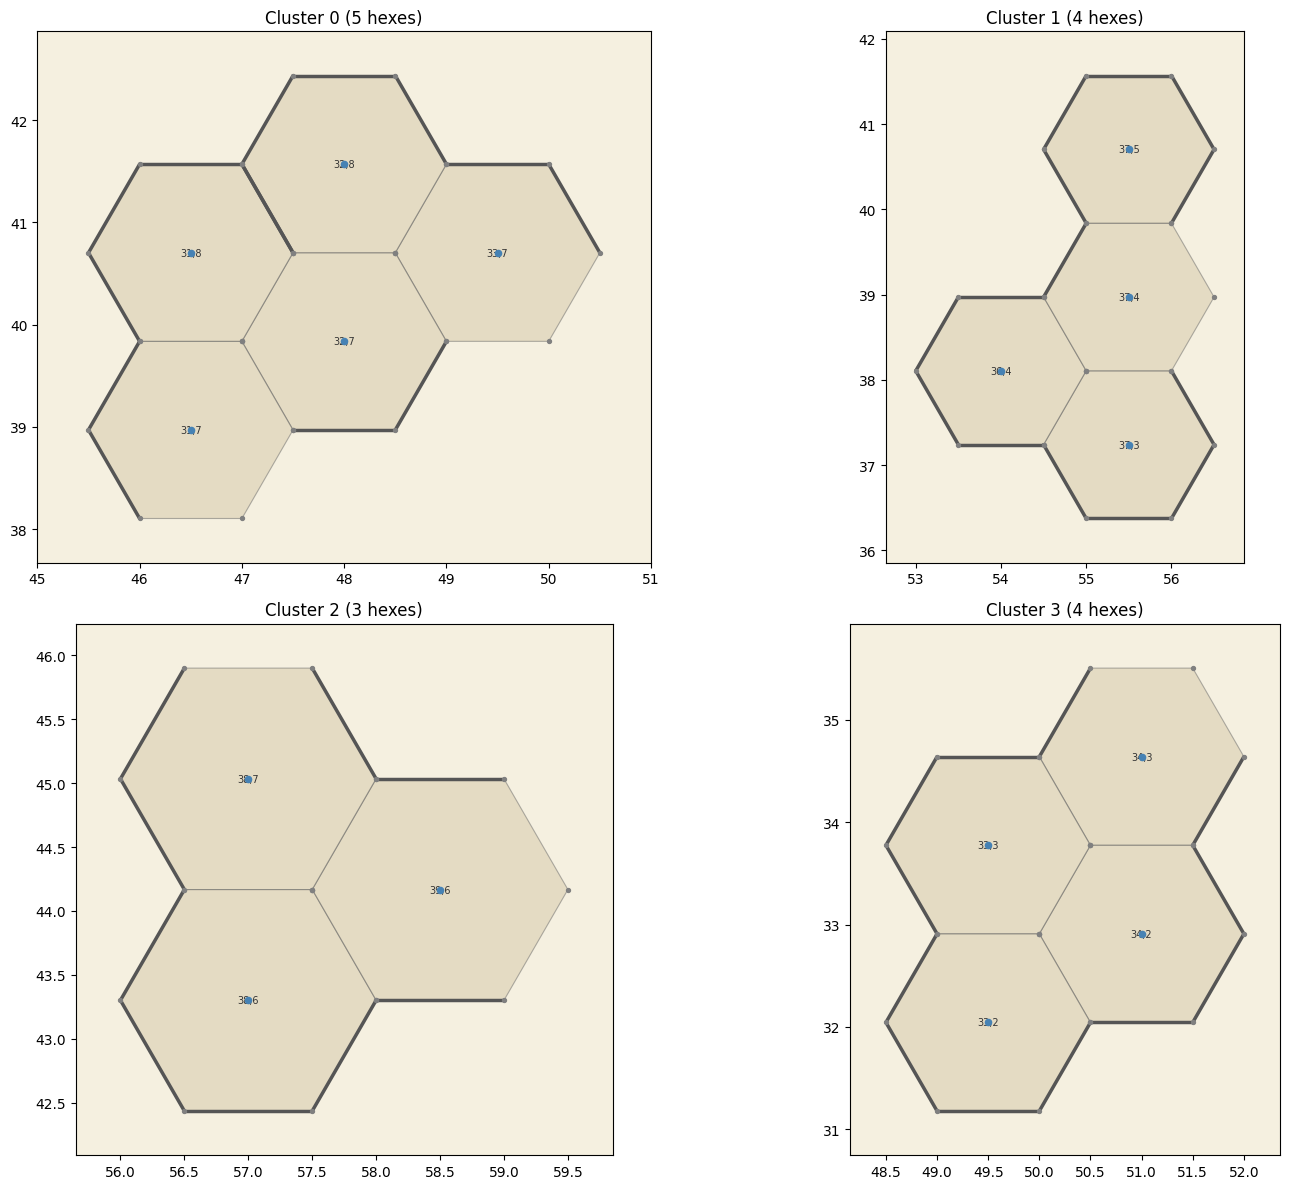

In [4]:
# --- Demo: show all 4 clusters side by side ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, ax in enumerate(axes.flat):
    if idx >= len(CLUSTERS): break
    cluster = CLUSTERS[idx]
    ax.set_aspect('equal')
    ax.set_facecolor('#f5f0e0')
    draw_cluster(ax, cluster)
    draw_mur(ax, cluster)
    for q, r in cluster:
        label_hex(ax, q, r)
        # show center as dot
        cx, cy = hex_center(q, r)
        ax.scatter([cx], [cy], color='steelblue', s=20, zorder=4)
        # show corners as small dots
        for c in hex_corners(q, r):
            ax.scatter([c[0]], [c[1]], color='gray', s=8, zorder=3)
    ax.autoscale(); ax.margins(0.1)
    ax.set_title(f'Cluster {idx} ({len(cluster)} hexes)')
plt.tight_layout()
plt.show()

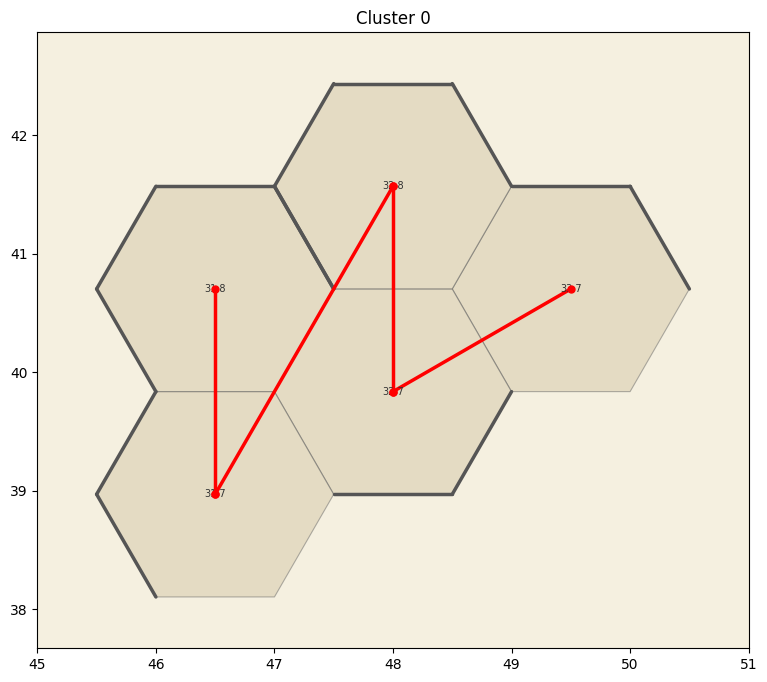

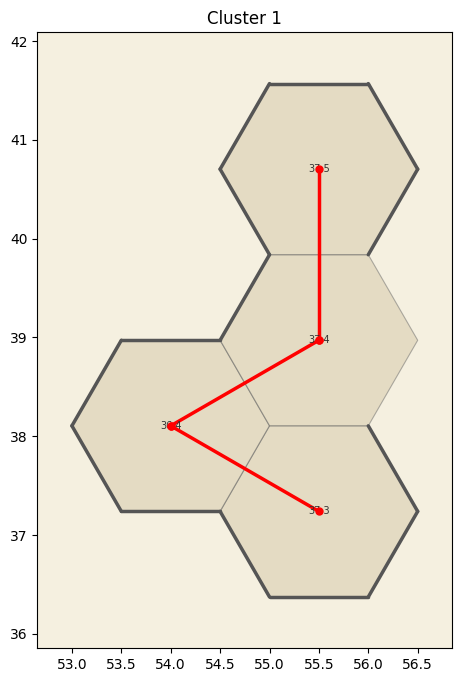

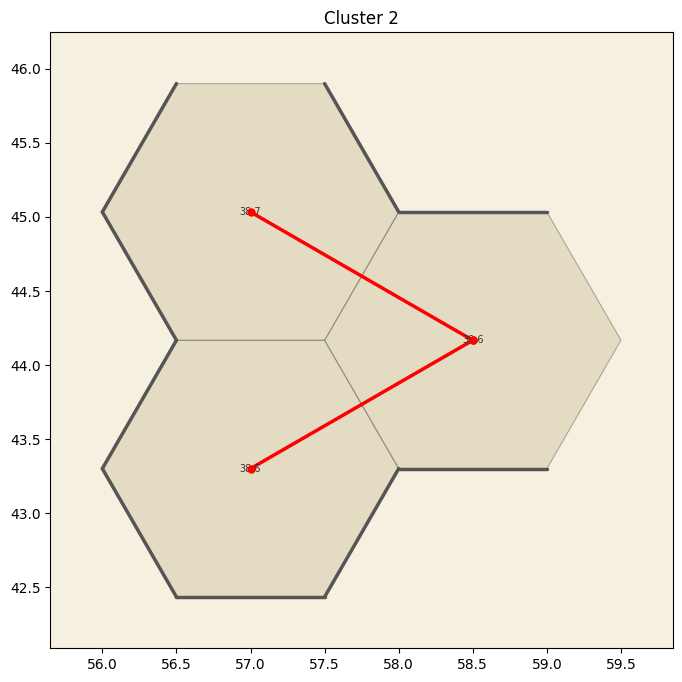

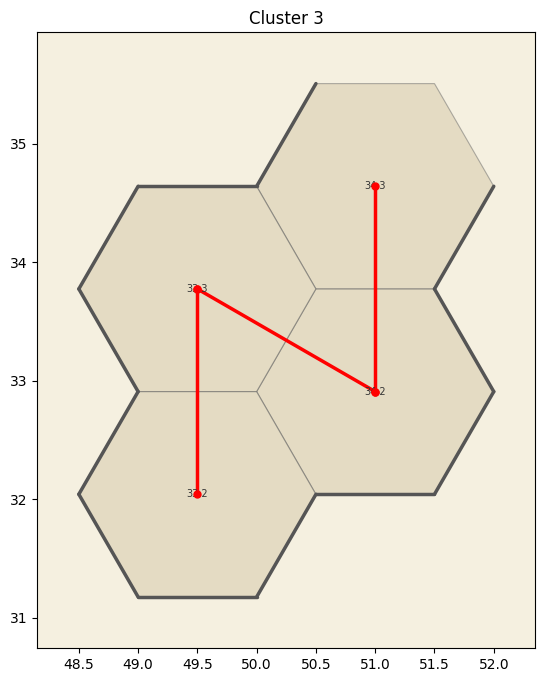

In [5]:
# --- Your ridge function goes here ---
# Write a function that takes a cluster (list of (q,r)) and returns
# a list of segments [((x0,y0),(x1,y1)), ...] representing the ridge.

def compute_ridge(cluster):
    """Return ridge segments for a cluster."""
    segments = []
    # Example: connect all centers in order
    for i in range(len(cluster) - 1):
        p0 = hex_center(*cluster[i])
        p1 = hex_center(*cluster[i+1])
        segments.append((p0, p1))
    return segments

# Draw it
for idx in range(len(CLUSTERS)):
    fig, ax = new_fig(idx)
    segs = compute_ridge(CLUSTERS[idx])
    draw_segments(ax, segs, color='red', lw=2.5)
    for p0, p1 in segs:
        draw_point(ax, p0, color='red', s=25)
        draw_point(ax, p1, color='red', s=25)
    plt.show()